# Malware Family classification using MAML.

  - Author: Jihoon Shin (University of Texas at El Paso)
  - Dataset: MaleVis



In [ ]:
# Directly use kaggle dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d sohamkumar1703/malevis-dataset

Dataset URL: https://www.kaggle.com/datasets/sohamkumar1703/malevis-dataset
License(s): unknown
100% 2.92G/2.92G [02:29<00:00, 21.1MB/s]
100% 2.92G/2.92G [02:29<00:00, 20.9MB/s]


In [ ]:
!unzip malevis-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: malevis_train_val_300x300/val/Adposhel/f73fe023c9e448d2db5feae09a36652a7af86fedresized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/f7a12363c4aefdfe3e209d599c4f67b07680c094resized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/f89e5fc378142b7e595d30499a0d95d529f0c1d1resized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/f94fae61ce46f1aa106ffc105d6dfde631047108resized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/f9c02e71f1d20940572f5a193af57f11fbba8a95resized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/f9d1e3dfc70b1fbc01a86515b6c59eae20cc0858resized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/fa440d8624930396cc8ce9126169ca7cf9d9f333resized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/fa487403f7a4b07c9b77c43efe8c05e645b346adresized_image.png  
  inflating: malevis_train_val_300x300/val/Adposhel/f

In [ ]:
from PIL import Image
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import copy

%matplotlib inline

In [ ]:
# Flatten Each Image from 2D to 1D.
class FlattenedImageDataset(torch.utils.data.Dataset):
  def __init__(self, root, transform=None):
    self.dataset = datasets.ImageFolder(root=root, transform=transform)
    self.class_to_idx = self.dataset.class_to_idx
    self.classes = self.dataset.classes

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    image, label = self.dataset[idx]
    image = image.view(-1)  # Flatten the image
    return image, label

transform = transforms.Compose([
    transforms.Resize((300, 300)), # resize images for just in case
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize images
])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Create flatten datasets
train_dataset = FlattenedImageDataset(root='/content/malevis_train_val_300x300/train', transform=transform)
val_dataset = FlattenedImageDataset(root='/content/malevis_train_val_300x300/val', transform=transform)
print(f"▶ train_dataset: {len(train_dataset)}")
print(f"▶ val_dataset: {len(val_dataset)}")

num_classes = len(train_dataset.class_to_idx)
print(f"Number of classes in train_dataset: {num_classes}")
class_names = train_dataset.classes
print(f"Class names in train_dataset: {class_names}")

num_classes = len(val_dataset.class_to_idx)
print(f"Number of classes in validation_dataset: {num_classes}")
class_names = val_dataset.classes
print(f"Class names in validation_dataset: {class_names}")

▶ train_dataset: 9100
▶ val_dataset: 5126
Number of classes in train_dataset: 26
Class names in train_dataset: ['Adposhel', 'Agent', 'Allaple', 'Amonetize', 'Androm', 'Autorun', 'BrowseFox', 'Dinwod', 'Elex', 'Expiro', 'Fasong', 'HackKMS', 'Hlux', 'Injector', 'InstallCore', 'MultiPlug', 'Neoreklami', 'Neshta', 'Other', 'Regrun', 'Sality', 'Snarasite', 'Stantinko', 'VBA', 'VBKrypt', 'Vilsel']
Number of classes in validation_dataset: 26
Class names in validation_dataset: ['Adposhel', 'Agent', 'Allaple', 'Amonetize', 'Androm', 'Autorun', 'BrowseFox', 'Dinwod', 'Elex', 'Expiro', 'Fasong', 'HackKMS', 'Hlux', 'Injector', 'InstallCore', 'MultiPlug', 'Neoreklami', 'Neshta', 'Other', 'Regrun', 'Sality', 'Snarasite', 'Stantinko', 'VBA', 'VBKrypt', 'Vilsel']


In [ ]:
label_to_index = {label: idx for idx, label in enumerate(class_names)}
print(label_to_index)
# Define a function to filter and save dataset
def filter_and_save_dataset(original_dataset, classes_to_keep, file_path, label_mapping):
    indices = [i for i, (_, label) in enumerate(original_dataset) if original_dataset.classes[label] in classes_to_keep]
    filtered_data = [(image, label_mapping[original_dataset.classes[label]]) for i, (image, label) in enumerate(original_dataset) if i in indices]

    torch.save(filtered_data, file_path)

{'Adposhel': 0, 'Agent': 1, 'Allaple': 2, 'Amonetize': 3, 'Androm': 4, 'Autorun': 5, 'BrowseFox': 6, 'Dinwod': 7, 'Elex': 8, 'Expiro': 9, 'Fasong': 10, 'HackKMS': 11, 'Hlux': 12, 'Injector': 13, 'InstallCore': 14, 'MultiPlug': 15, 'Neoreklami': 16, 'Neshta': 17, 'Other': 18, 'Regrun': 19, 'Sality': 20, 'Snarasite': 21, 'Stantinko': 22, 'VBA': 23, 'VBKrypt': 24, 'Vilsel': 25}


In [ ]:
''' --- [Set the number of classes and Split the dataset] --- '''
num_classes = len(class_names)  # Number of unique malware families
print(f"Number of classes: {num_classes}")
num_classes_training = 18  # Number of classes for training
num_classes_testing = num_classes - num_classes_training # Number of classes for testing

num_sampled_class_training = 5 # 5 classes will be sampled from the 18 (num_classes_training) classes in Training Task class.
num_sampled_class_testing = 3 # 3 classes will be sampled from the 6 (num_classes_testing) classes in Testing Task class.

Number of classes: 26


In [ ]:
# Split the classes into Training and Testing
training_classes = random.sample(class_names, num_classes_training) # dataset for the training
testing_classes = [label for label in class_names if label not in training_classes] # dataset for the testing which is not in training_classes

print(f"training_classes: {training_classes}")
print(f"testing_classes: {testing_classes}")

# Filter dataset using class names
filter_and_save_dataset(train_dataset, training_classes, 'filtered_train_dataset.pt', label_to_index)
filter_and_save_dataset(val_dataset, testing_classes, 'filtered_val_dataset.pt', label_to_index)

filtered_train_dataset = torch.load('filtered_train_dataset.pt')
filtered_val_dataset = torch.load('filtered_val_dataset.pt')

training_classes: ['Autorun', 'BrowseFox', 'Expiro', 'Snarasite', 'Sality', 'Agent', 'Hlux', 'Neshta', 'Other', 'Allaple', 'Regrun', 'Adposhel', 'Amonetize', 'VBA', 'Elex', 'InstallCore', 'Dinwod', 'Injector']
testing_classes: ['Androm', 'Fasong', 'HackKMS', 'MultiPlug', 'Neoreklami', 'Stantinko', 'VBKrypt', 'Vilsel']


<ipython-input-8-b871b6dd0789>:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  filtered_train_dataset = torch.load('filtered_train_dataset.pt')
<ipython-input-8-b871b6dd07

In [ ]:
train_labels = set(label for _, label in filtered_train_dataset)
val_labels = set(label for _, label in filtered_val_dataset)

training_classes = train_labels
testing_classes = val_labels

# Print encoded labels in both datasets
print(f"Unique encoded labels in filtered_train_dataset: {sorted(train_labels)}")
print(f"Unique encoded labels in filtered_val_dataset: {sorted(val_labels)}")

# Ensure there is no overlap between training and validation labels
common_labels = train_labels.intersection(val_labels)
if common_labels:
    print(f"Warning: Overlapping labels found! {common_labels}")
else:
    print("No overlap between training and validation labels. Encoding is consistent!")

# Print the mapping to double-check
print("\nLabel Encoding Mapping:")
for class_name, encoded_label in label_to_index.items():
    print(f"{class_name}: {encoded_label}")

Unique encoded labels in filtered_train_dataset: [0, 1, 2, 3, 5, 6, 7, 8, 9, 12, 13, 14, 17, 18, 19, 20, 21, 23]
Unique encoded labels in filtered_val_dataset: [4, 10, 11, 15, 16, 22, 24, 25]
No overlap between training and validation labels. Encoding is consistent!

Label Encoding Mapping:
Adposhel: 0
Agent: 1
Allaple: 2
Amonetize: 3
Androm: 4
Autorun: 5
BrowseFox: 6
Dinwod: 7
Elex: 8
Expiro: 9
Fasong: 10
HackKMS: 11
Hlux: 12
Injector: 13
InstallCore: 14
MultiPlug: 15
Neoreklami: 16
Neshta: 17
Other: 18
Regrun: 19
Sality: 20
Snarasite: 21
Stantinko: 22
VBA: 23
VBKrypt: 24
Vilsel: 25


In [ ]:
# Print the filtered dataset
for i, (image, label) in enumerate(filtered_train_dataset):
    print(f"Sample {i+1}:")
    print(f"Label (Class Name): {label}")
    print(f"Image Tensor Shape: {image.shape}") # image dimensions
    print(f"Image: {image}")
    print()
    if i >= 2:  # Prints the first 3 samples
        break

print(f"Unique num_classes: {num_classes} (classes for training: {num_classes_training} / for testing: {num_classes_testing})")
print(f"Total number of Loaded data: {len(filtered_train_dataset)+len(filtered_val_dataset)} = train:{len(filtered_train_dataset)} + val:{len(filtered_val_dataset)}")
print(f"* MetaTraining:")
print(f"  - Sampled Classes for MetaTrainingTask: {len(training_classes)} = {training_classes}")
print(f"  - number of MetaTraining data: {len(filtered_train_dataset)}")
print(f"* MetaTesting:")
print(f"  - Sampled Classes for MetaTestingTask: {len(testing_classes)} = {testing_classes}")
print(f"  - number of MetaTesting data: {len(filtered_val_dataset)}")

Sample 1:
Label (Class Name): 0
Image Tensor Shape: torch.Size([270000])
Image: tensor([-1.3473, -1.7240, -1.2788,  ..., -1.2119, -0.5670, -1.1596])

Sample 2:
Label (Class Name): 0
Image Tensor Shape: torch.Size([270000])
Image: tensor([-0.3883, -0.1486, -1.0048,  ..., -1.4733, -1.4036, -1.7347])

Sample 3:
Label (Class Name): 0
Image Tensor Shape: torch.Size([270000])
Image: tensor([-1.2445, -1.0390, -2.0837,  ..., -1.0550, -0.4798, -1.2293])

Unique num_classes: 26 (classes for training: 18 / for testing: 8)
Total number of Loaded data: 7490 = train:6300 + val:1190
* MetaTraining:
  - Sampled Classes for MetaTrainingTask: 18 = {0, 1, 2, 3, 5, 6, 7, 8, 9, 12, 13, 14, 17, 18, 19, 20, 21, 23}
  - number of MetaTraining data: 6300
* MetaTesting:
  - Sampled Classes for MetaTestingTask: 8 = {4, 10, 11, 15, 16, 22, 24, 25}
  - number of MetaTesting data: 1190


In [ ]:
# class for the Training Task & Testing Task
class MetaTrainingTask(object):
  def __init__(self, train_dataset, training_classes, num_sampled_class_training, num_sample_per_class, num_support_instances, num_query_instances, mode):
    self.train_dataset = train_dataset  # part of loaded_data which only has classes for training.
    self.num_classes = num_sampled_class_training  # number of classes in each task
    self.num_support_instances = num_support_instances  # number of instances per class in the support set
    self.num_query_instances = num_query_instances  # number of instances per class in the query set
    self.support_vectors = []
    self.support_labels = []
    self.query_vectors = []
    self.query_labels = []

    sampled_classes = random.sample(list(training_classes), self.num_classes)  # sample classes for training

    if mode == 'verbose':
      print("MetaTrainingTask - sampled classes: ", sampled_classes)

    for label in sampled_classes:
      samples = [image for image, lbl in self.train_dataset if lbl == label]

      if len(samples) < num_sample_per_class:
        raise ValueError(f"[MetaTraining] Not enough samples for class {label}, ({len(samples)}).")
      sample_idxs = np.random.choice(len(samples), num_sample_per_class, replace=False)  # randomly shuffle and get sample as num_sample_per_class

      # support_samples: used for training (inner loop in MAML).
      support_samples = sample_idxs[:self.num_support_instances]
      # query_samples: use to evaluate the model's performance on that specific task.
      query_samples = sample_idxs[self.num_support_instances:self.num_support_instances + num_query_instances]

      # Used in the inner loop.
      self.support_vectors.append(torch.stack([samples[i] for i in support_samples], dim=0))
      self.support_labels.extend([label] * len(support_samples))

      # Used in the outer loop (meta-training).
      self.query_vectors.append(torch.stack([samples[i] for i in query_samples], dim=0))
      self.query_labels.extend([label] * len(query_samples))

      if mode == 'verbose':
        print(f"  - Samples for [{label}] count: {len(sample_idxs)} = support_samples: {len(support_samples)} + query_samples: {len(query_samples)}")
        print(f"  - support_labels: {self.support_labels}")
        print(f"  - support_vectors: {self.support_vectors[0].shape}")
        print(f"  - query_labels: {self.query_labels}")
        print(f"  - query_vectors: {self.query_vectors[0].shape}")
        print()

    # Convert lists to tensors
    self.support_vectors = torch.cat(self.support_vectors, dim=0)
    self.support_labels = torch.tensor(self.support_labels, dtype=torch.long)
    self.query_vectors = torch.cat(self.query_vectors, dim=0)
    self.query_labels = torch.tensor(self.query_labels, dtype=torch.long)

    if mode == 'verbose':
      print(f"  > support_vector: {len(self.support_vectors)}, support_labels: {len(self.support_labels)} | query_vector: {len(self.query_vectors)} / query_labels: {len(self.query_labels)}")

  def __len__(self):
    return len(self.query_labels)

  def __getitem__(self, idx):
    return self.query_vectors[idx], self.query_labels[idx]

# generates test tasks for evaluating the model after training.
class MetaTestingTask(object):
  def __init__(self, test_dataset, testing_classes, num_sampled_class_testing, num_sample_per_class, num_support_instances, num_query_instances, mode):
    self.test_dataset = test_dataset  # part of loaded_data which only has classes for testing.
    self.num_classes = num_sampled_class_testing
    self.num_support_instances = num_support_instances  # number of instances per class in the support set
    self.num_query_instances = num_query_instances  # number of instances per class in the query set
    self.support_vectors = []
    self.support_labels = []
    self.query_vectors = []
    self.query_labels = []

    sampled_classes = random.sample(list(testing_classes), self.num_classes)  # sample classes for testing
    if mode == 'verbose':
      print("MetaTestingTask - sampled classes: ", sampled_classes)

    for label in sampled_classes:
      samples = [image for image, lbl in self.test_dataset if lbl == label]

      if len(samples) < num_sample_per_class:
        raise ValueError(f"[MetaTesting] Not enough samples for class {label}, ({len(samples)}).")
      sample_idxs = np.random.choice(len(samples), num_sample_per_class, replace=False)  # randomly shuffle and select

      # support_samples: use to adapt the model to the new task.
      support_samples = sample_idxs[:self.num_support_instances]
      # query_samples: use to evaluate the model's performance on this task after adaptation.
      query_samples = sample_idxs[self.num_support_instances:self.num_support_instances + self.num_query_instances]

      # Used for quick adaptation in the testing phase.
      self.support_vectors.append(torch.stack([samples[i] for i in support_samples], dim=0))
      self.support_labels.extend([label] * len(support_samples))

      # Used to evaluate the model's performance on new tasks.
      self.query_vectors.append(torch.stack([samples[i] for i in query_samples], dim=0))
      self.query_labels.extend([label] * len(query_samples))

      if mode == 'verbose':
        print(f"  - Samples for [{label}] count: {len(sample_idxs)} = support_samples: {len(support_samples)} + query_samples: {len(query_samples)}")
        print(f"  - support_labels: {self.support_labels}")
        print(f"  - support_vectors: {self.support_vectors[0].shape}")
        print(f"  - query_labels: {self.query_labels}")
        print(f"  - query_vectors: {self.query_vectors[0].shape}")
        print()

    # Convert lists to tensors
    self.support_vectors = torch.cat(self.support_vectors, dim=0)
    self.support_labels = torch.tensor(self.support_labels, dtype=torch.long)
    self.query_vectors = torch.cat(self.query_vectors, dim=0)
    self.query_labels = torch.tensor(self.query_labels, dtype=torch.long)

    if mode == 'verbose':
      print(f"  > support_vector: {len(self.support_vectors)}, support_labels: {len(self.support_labels)} | query_vector: {len(self.query_vectors)} / query_labels: {len(self.query_labels)}")

  def __len__(self):
    return len(self.query_labels)

  def __getitem__(self, idx):
    return self.query_vectors[idx], self.query_labels[idx]

In [ ]:
''' BaseNet for Malevis dataset
    - ref. https://github.com/Alexander-H-Liu/MalConv-Pytorch/blob/master/src/util.py

    - input_length = total number of features for each image after flattening.
                   → 3 channels * 300 * 300 = 270000
    - window_size = refers to the kernel size.
                  (how manu neighboring features (pixels in the flattened array) will be considered at once.)
                  start with from 3, 5, 7, 15

'''
class BaseNet(nn.Module):
  def __init__(self, input_length = 270000, window_size = 5, num_classes=26):
    super(BaseNet, self).__init__()

    self.embed_1 = nn.Linear(270000, 257)
    self.embed_2 = nn.Linear(in_features=257, out_features=128)
    self.conv_1 = nn.Conv1d(in_channels=1, out_channels=1, padding=1, stride=1, kernel_size=3, bias=True)
    self.conv_2 = nn.Conv1d(in_channels=1, out_channels=1, padding=1, stride=1, kernel_size=3, bias=True)

    self.pooling = nn.MaxPool1d(kernel_size=2, stride=2)
    #self.pooling = nn.MaxPool1d( int(input_length/window_size), stride=2) # it could lose a lot of information.(?)

    self.fc_1 = nn.Linear(64, 128)
    self.fc_2 = nn.Linear(128, num_classes)

    self.softmax = nn.Softmax() # multi-class classiciation.

  def forward(self, x, weight=None):
    x = x.view(x.size(0), 1, -1)

    if weight is None:
      # Forward pass through convolutional layers
      x = self.embed_2(self.embed_1(x))
      cnn_value = self.conv_1(x)
      gating_weight = torch.sigmoid(self.conv_2(x))

      x = cnn_value * gating_weight  # Element-wise multiplication for gating
      x = self.pooling(x)
      x = x.view(x.size(0), -1)
      x = self.fc_1(x)
      x = self.fc_2(x)

    else:
      x = F.linear(x, weight['embed_1.weight'], weight['embed_1.bias'])
      x = F.linear(x, weight['embed_2.weight'], weight['embed_2.bias'])
      cnn_value = F.conv1d(x, weight['conv_1.weight'], weight['conv_1.bias'], stride=1, padding=1, dilation=1, groups=1)
      gating_weight = torch.sigmoid(F.conv1d(x, weight['conv_2.weight'], weight['conv_2.bias'], stride=1, padding=1, dilation=1, groups=1))
      x = cnn_value * gating_weight
      x = F.max_pool1d(x, kernel_size=2, stride=2)
      x = x.view(x.size(0), -1)
      x = F.linear(x, weight['fc_1.weight'], weight['fc_1.bias'])
      x = F.linear(x, weight['fc_2.weight'], weight['fc_2.bias'])

    return self.softmax(x)  # Return softmax probabilities

In [ ]:
# Meta Learner
class MAML(nn.Module):
  def __init__(self, model, inner_lr, outer_lr, num_inner_steps, mode='verbose'):
    super(MAML, self).__init__()
    self.model = model
    self.inner_lr = inner_lr  # learning rate for Inner loop updates
    self.outer_lr = outer_lr  # learning rate for Outer loop updates
    self.num_inner_steps = num_inner_steps  # number of steps for Inner loop updates
    self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.outer_lr)
    self.mode = mode

   # Inner Loop (Task-Specific Training)
  def inner_loop(self, support_vectors, support_labels):
    task_loss_fn = nn.CrossEntropyLoss()

    # Clone current weights (to avoid modifying the main model)
    temp_model = {name: param.clone() for name, param in self.model.named_parameters()}

    for _ in range(self.num_inner_steps):
      # Forward pass with fast weights
      preds = self.model(support_vectors, weight=temp_model)
      loss = task_loss_fn(preds, support_labels)

      if self.mode == 'verbose_maml':
        print(f"[Inner Loop] loss: {loss}")
      # Compute gradients with respect to current fast weights
      grads = torch.autograd.grad(loss, temp_model.values(), create_graph=True, allow_unused=True)

      # Perform gradient update on fast weights
      temp_model = {name: param - self.inner_lr * grad for (name, param), grad in
                      zip(temp_model.items(), grads)}

    return temp_model  # Return the fast weights

  # Outer Loop (Meta-Update)
  def outer_loop(self, meta_tasks):
    total_loss = 0
    total_accuracy = 0
    cnt = 0 # for log

    for task in meta_tasks:
      # [Module Test] Log the loss value
      if self.mode == 'verbose_maml':
        initial_predictions = self.model(task.support_vectors)
        initial_loss = F.cross_entropy(initial_predictions, task.support_labels)
        print(f"[Outer Loop({cnt}/{len(meta_tasks)})] Initial Loss: {initial_loss.item()}")

      temp_model = self.inner_loop(task.support_vectors, task.support_labels)
      predictions = self.model(task.query_vectors, weight=temp_model)
      loss = F.cross_entropy(predictions, task.query_labels)
      total_loss += loss

      correct_preds = (torch.argmax(predictions, dim=1) == task.query_labels).float()
      accuracy = correct_preds.mean().item()
      total_accuracy += accuracy

      if self.mode == 'verbose_maml':
        print(f"[Outer Loop({cnt}/{len(meta_tasks)})] Initial Loss: {initial_loss.item()}, Final Loss: {loss.item()} | total loss= {total_loss}")  # for log
        cnt += 1 # for log

    total_loss /= len(meta_tasks)
    total_accuracy /= len(meta_tasks)

    if self.mode == 'verbose_maml':
      print(f"[Outer Loop] Total Loss: {total_loss}")

    self.optimizer.zero_grad()  # set the gradients to zero before starting to do backpropagation.
    total_loss.backward() # Compute gradients with respect to the main model's parameters

    if self.mode == 'verbose_maml':
      for name, param in self.model.named_parameters(): # code to check
        print(f"Parameter: {name}, Values: {param.data}")
        if param.grad is not None:
            grad_norm = param.grad.norm()
            print(f'Gradient norm for {name}: {grad_norm}')
        else:
            print(f'No gradients computed for {name}')

    self.optimizer.step() # applies the computed gradients to update the model's parameters

    return total_loss, total_accuracy

  def evaluate(self, task):
    temp_model = self.inner_loop(task.support_vectors, task.support_labels)
    predictions = self.model(task.query_vectors, weight=temp_model)
    loss = F.cross_entropy(predictions, task.query_labels)

    # compute accuracy
    predicted_labels = torch.argmax(predictions, dim=1)
    corrected_predictions = (predicted_labels == task.query_labels).sum().item()
    accuracy = corrected_predictions / len(task.query_labels)

    return loss.item(), accuracy

In [ ]:
''' --- [▶ Printing the process to check the process] --- '''
# 1) for checkging Tasks part: verbose
# mode = 'verbose'
# 2) for checking MAML class part: verbose_maml
# mode = 'verbose_maml'
# 3) for just printing the loss and accuracy information
mode = 'normal'
''' --------------------------------------------------------- '''
''' --- [Set the hyperparameters] --- '''
inner_lr = 0.01  # Learning rate for inner loop
outer_lr = 0.005  # Learning rate for outer loop

num_meta_tasks = 5         # Number of meta-training & meta-testing tasks per epoch (Increased from 20)
num_inner_steps = 40       # Number of inner loop steps (Increased from 10)
num_epochs = 50             # Number of meta-training epochs (Increased from 100)

num_samples_per_class = 50 # Number of samples per class
num_support_instances = 20  # Number of support instances per class
num_query_instances = 30  # Number of query instances per class

# Initialize the model and MAML
model = BaseNet(num_classes)
maml = MAML(model, inner_lr, outer_lr, num_inner_steps, mode)

In [ ]:
''' Checking the model. '''
meta_loss_list = []
meta_acc_list = []
val_loss_list = []
val_acc_list = []

for epoch in range(num_epochs):
  # generate meta-training tasks
  meta_tasks = [MetaTrainingTask(filtered_train_dataset, training_classes, num_sampled_class_training, num_samples_per_class, num_support_instances, num_query_instances, mode) for _ in range(num_meta_tasks)]

  if mode in ('verbose', 'verbose_maml'):
    print(f"number of meta_tasks: {len(meta_tasks)}")

  # perform meta-training
  meta_loss, meta_acc = maml.outer_loop(meta_tasks)
  meta_loss_list.append(meta_loss)
  meta_acc_list.append(meta_acc)
  # Compute change direction for loss and accuracy
  if len(meta_loss_list) > 1:  # Ensure there is a previous value to compare
      loss_trend = "↑" if meta_loss > meta_loss_list[-2] else "↓"
      acc_trend = "↑" if meta_acc > meta_acc_list[-2] else "↓"
  else:
      loss_trend = acc_trend = "-"

  # if (epoch+1) % 10 == 0:
  print(f'Epoch {(epoch+1)}/{num_epochs}, Meta Loss: {meta_loss:.8f} {loss_trend}, Meta Accuracy: {meta_acc:.2f} {acc_trend} ')

  # validation
  meta_testing_tasks = [MetaTestingTask(filtered_val_dataset, testing_classes, num_sampled_class_testing, num_samples_per_class, num_support_instances, num_query_instances, mode) for _ in range(num_meta_tasks)]
  total_test_loss = 0
  total_test_acc = 0

  for task in meta_testing_tasks:
    test_loss, test_acc = maml.evaluate(task)
    total_test_loss += test_loss
    total_test_acc += test_acc

  avg_test_loss = total_test_loss / len(meta_testing_tasks)
  avg_test_acc = total_test_acc / len(meta_testing_tasks)

  val_loss_list.append(avg_test_loss)
  val_acc_list.append(avg_test_acc)

  # Compute change direction for loss and accuracy
  if len(val_loss_list) > 1:  # Ensure there is a previous value to compare
      loss_trend = "↑" if avg_test_loss > val_loss_list[-2] else "↓"
      acc_trend = "↑" if avg_test_acc > val_acc_list[-2] else "↓"
  else:
      loss_trend = acc_trend = "-"

  print(f'Epoch {(epoch+1)}/{num_epochs}, Validation Loss: {avg_test_loss:.8f} {loss_trend}, Validation Accuracy: {avg_test_acc:.2f} {acc_trend}')

print("Training Completed.")

Epoch 1/50, Meta Loss: 3.05165625 -, Meta Accuracy: 0.40 - 
Epoch 1/50, Validation Loss: 3.32001977 -, Validation Accuracy: 0.00 -
Epoch 2/50, Meta Loss: 3.11146402 ↑, Meta Accuracy: 0.21 ↓ 
Epoch 2/50, Validation Loss: 3.32207355 ↑, Validation Accuracy: 0.00 ↓
Epoch 3/50, Meta Loss: 3.30586576 ↑, Meta Accuracy: 0.02 ↓ 
Epoch 3/50, Validation Loss: 3.32209044 ↑, Validation Accuracy: 0.00 ↓
Epoch 4/50, Meta Loss: 3.23271060 ↓, Meta Accuracy: 0.09 ↑ 
Epoch 4/50, Validation Loss: 3.32206602 ↓, Validation Accuracy: 0.00 ↓
Epoch 5/50, Meta Loss: 3.29667711 ↑, Meta Accuracy: 0.03 ↓ 
Epoch 5/50, Validation Loss: 3.32205138 ↓, Validation Accuracy: 0.00 ↓
Epoch 6/50, Meta Loss: 3.23083425 ↓, Meta Accuracy: 0.09 ↑ 
Epoch 6/50, Validation Loss: 3.32207737 ↑, Validation Accuracy: 0.00 ↓
Epoch 7/50, Meta Loss: 3.21814728 ↓, Meta Accuracy: 0.10 ↑ 
Epoch 7/50, Validation Loss: 3.32209301 ↑, Validation Accuracy: 0.00 ↓
Epoch 8/50, Meta Loss: 3.32208776 ↑, Meta Accuracy: 0.00 ↓ 
Epoch 8/50, Validation 

KeyboardInterrupt: 

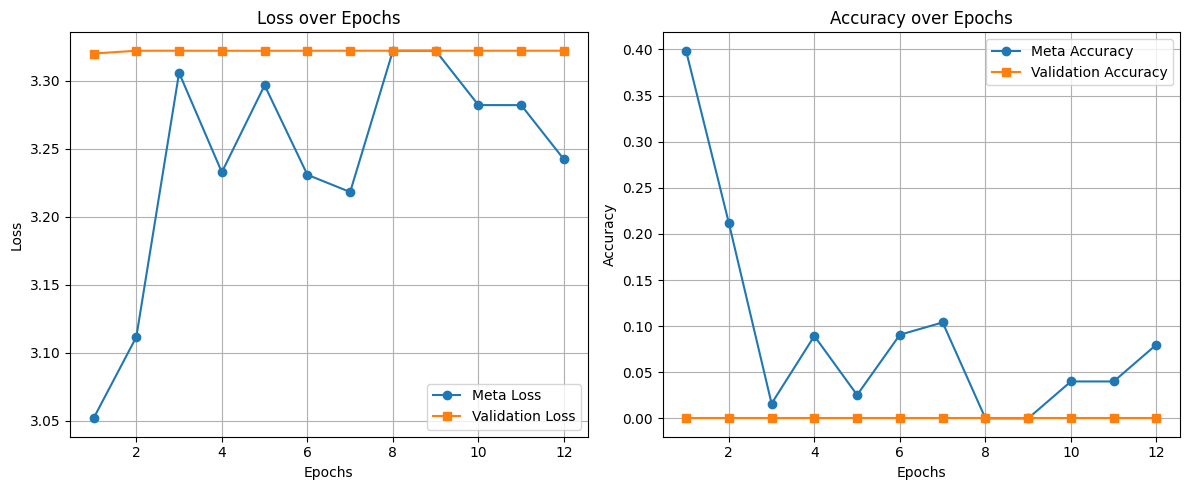

In [ ]:
# Create subplots for loss and accuracy
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Meta Loss and Validation Loss
axs[0].plot(range(1, len(meta_loss_list) + 1), [loss.detach().numpy() for loss in meta_loss_list], label="Meta Loss", marker="o")
axs[0].plot(range(1, len(val_loss_list) + 1), val_loss_list, label="Validation Loss", marker="s")
axs[0].set_title("Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid()

# Plot Meta Accuracy and Validation Accuracy
axs[1].plot(range(1, len(meta_acc_list) + 1), meta_acc_list, label="Meta Accuracy", marker="o")
axs[1].plot(range(1, len(val_acc_list) + 1), val_acc_list, label="Validation Accuracy", marker="s")
axs[1].set_title("Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid()

# Show the plot
plt.tight_layout()
plt.show()